<a href="https://colab.research.google.com/github/AngryWeassel/Proyecto_Tasa_de_Natalidad.ipynb/blob/main/Proyecto_Tasa_de_Natalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt

#Importación de lista de Paises de la OECD
#Fuente: Consulta en Google y creación de Excel manual
archivo_nombres_oecd = 'https://docs.google.com/spreadsheets/d/1gpatuWv1C5Iq14sTngbqZV01PtK4T-1VuIty43tDE58/edit?usp=drive_link'
nombres_oecd = gdown.download(archivo_nombres_oecd, quiet=True, fuzzy=True)
oecd = pd.read_excel(nombres_oecd)

#Importación de datos del PIB(en ingles GDP) de los paises a nivel global
#Fuente:
archivo_gdp = 'https://drive.google.com/file/d/1RWhkgYFs73Ya0XUdyNmeo8IZ7yLC7mxG/view?usp=sharing'
gpd = gdown.download(archivo_gdp, quiet=True, fuzzy=True)
datos_gdp = pd.read_csv(gpd)

In [2]:
diccionario_paises = {
    'Alemania': 'Germany',
    'Australia': 'Australia',
    'Austria': 'Austria',
    'Bélgica': 'Belgium',
    'Canadá': 'Canada',
    'Chile': 'Chile',
    'Colombia': 'Colombia',
    'Corea del Sur': 'South Korea',
    'Costa Rica': 'Costa Rica',
    'Dinamarca': 'Denmark',
    'Eslovenia': 'Slovenia',
    'España': 'Spain',
    'Estados Unidos': 'United States',
    'Estonia': 'Estonia',
    'Finlandia': 'Finland',
    'Francia': 'France',
    'Grecia': 'Greece',
    'Hungría': 'Hungary',
    'Irlanda': 'Ireland',
    'Islandia': 'Iceland',
    'Israel': 'Israel',
    'Italia': 'Italy',
    'Japón': 'Japan',
    'Letonia': 'Latvia',
    'Lituania': 'Lithuania',
    'Luxemburgo': 'Luxembourg',
    'México': 'Mexico',
    'Noruega': 'Norway',
    'Nueva Zelanda': 'New Zealand',
    'Países Bajos': 'Netherlands',
    'Polonia': 'Poland',
    'Portugal': 'Portugal',
    'Reino Unido': 'United Kingdom',
    'República Checa': 'Czechia',
    'República Eslovaca': 'Slovakia',
    'Suecia': 'Sweden',
    'Suiza': 'Switzerland',
    'Turquía': 'Turkey'
}
oecd['OECD Countries'] = oecd['Paises OCDE'].map(diccionario_paises)
inv_diccionario_paises = {v: k for k, v in diccionario_paises.items()}


In [3]:
oecd_list = oecd['OECD Countries'].tolist()

gdp_oecd = datos_gdp[
    (datos_gdp['Entity'].isin(oecd_list)) &
    (datos_gdp['Year'] >= 2014) &
    (datos_gdp['Year'] <= 2024)
]

In [4]:
gdp_oecd['Pais'] = gdp_oecd['Entity'].map(inv_diccionario_paises)

gdp_oecd = gdp_oecd.rename(columns={'GDP per capita': 'PIB por pais'})

/tmp/ipykernel_38316/2110056961.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdp_oecd['Pais'] = gdp_oecd['Entity'].map(inv_diccionario_paises)


In [5]:
gdp_oecd

,Entity,Code,Year,PIB por pais,World region according to OWID,Pais
328,Australia,AUS,2014,55489.070,Oceania,Australia
329,Australia,AUS,2015,55879.996,Oceania,Australia
330,Australia,AUS,2016,56529.953,Oceania,Australia
331,Australia,AUS,2017,56881.855,Oceania,Australia
332,Australia,AUS,2018,57647.844,Oceania,Australia
...,...,...,...,...,...,...
6934,United States,USA,2020,67342.070,North America,Estados Unidos
6935,United States,USA,2021,71307.400,North America,Estados Unidos
6936,United States,USA,2022,72679.260,North America,Estados Unidos
6937,United States,USA,2023,74158.720,North America,Estados Unidos


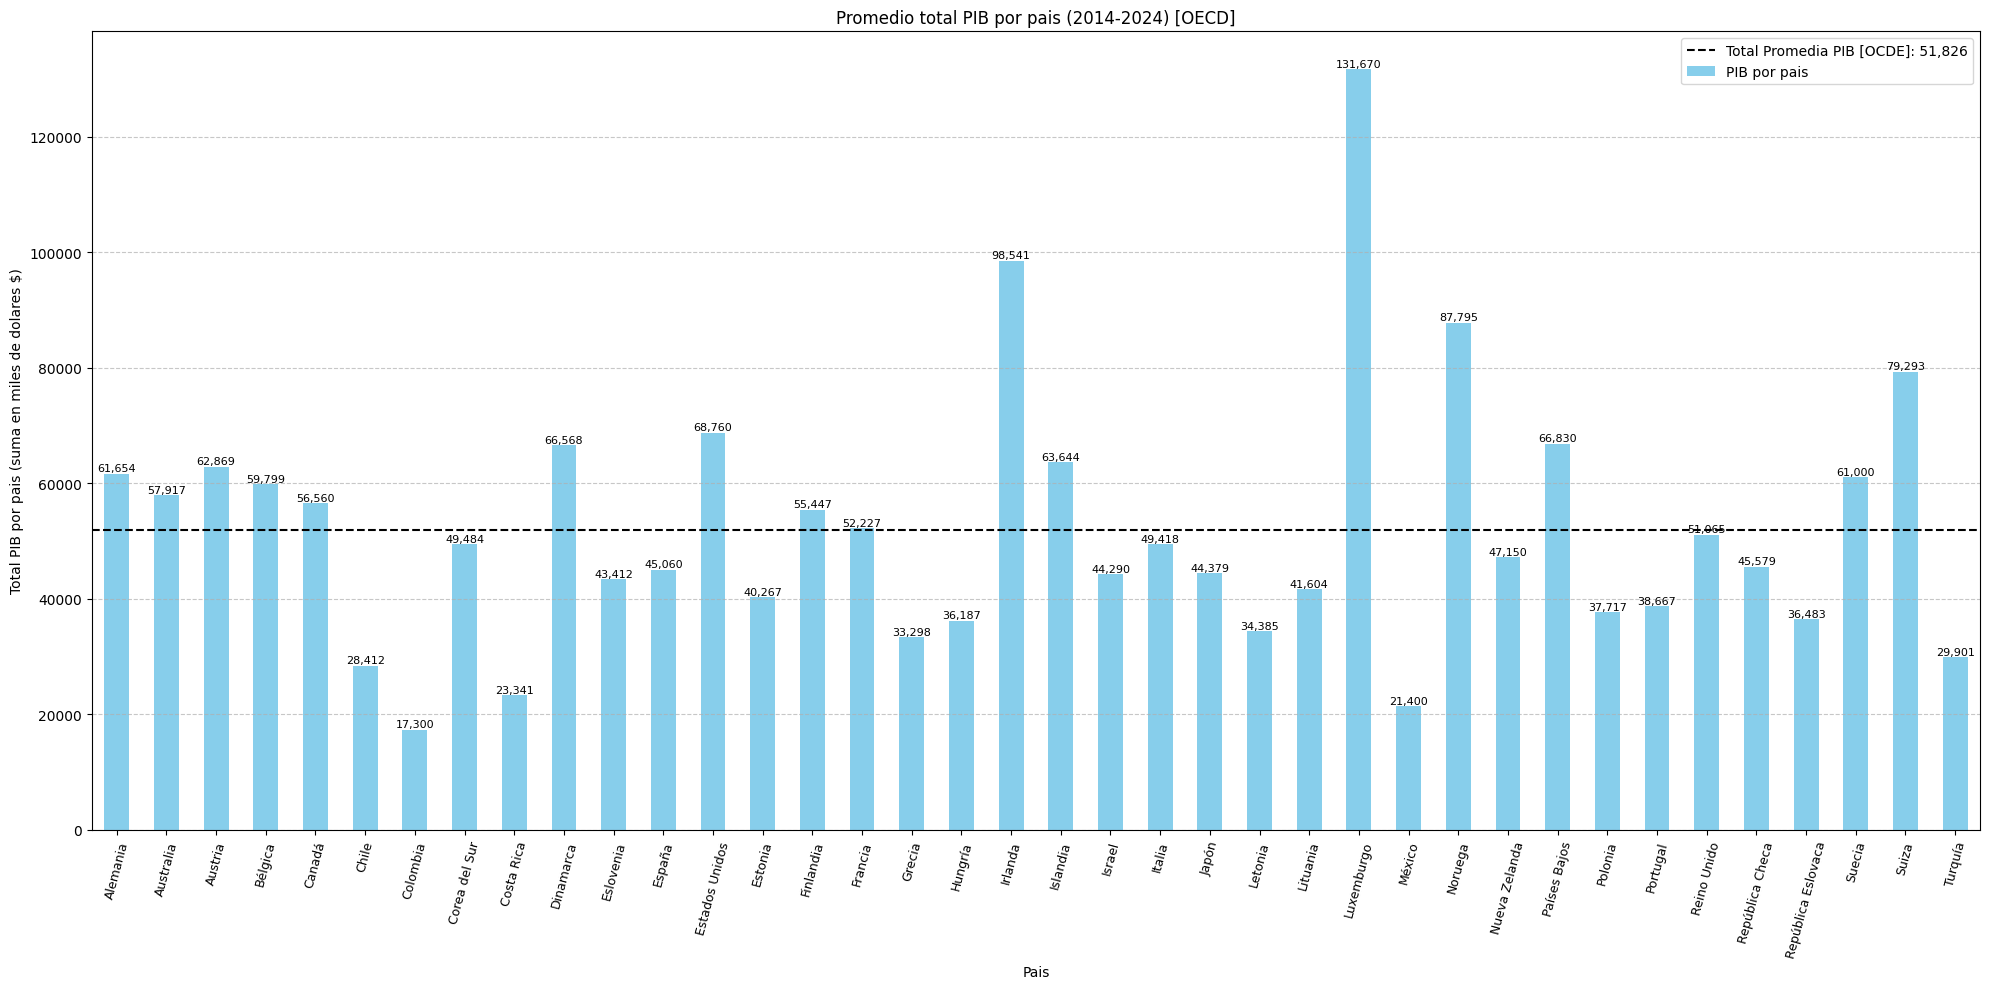

In [6]:
pais_gdp_sum = gdp_oecd.groupby('Pais')['PIB por pais'].mean()
plt.figure(figsize=(20, 10))
pais_gdp_sum.plot(kind='bar', color='skyblue')
plt.title('Promedio total PIB por pais (2014-2024) [OECD]')
plt.xlabel('Pais')
plt.ylabel('Total PIB por pais (suma en miles de dolares $)')
plt.xticks(rotation=75, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)

overall_gdp_average = gdp_oecd['PIB por pais'].mean()

plt.axhline(y=overall_gdp_average, color='k', linestyle='--', label=f'Total Promedia PIB [OCDE]: {overall_gdp_average:,.0f}')

for index, value in enumerate(pais_gdp_sum):
    plt.text(index, value + (max(pais_gdp_sum) * 0.0005), f'{value:,.0f}', ha='center', va='bottom', fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()